
# Exploratory Data Analysis (EDA) On Retail sales Dataset
## Task 1 : EDA on Retail Sales Data 
### Objective 
The objective of this project is to analyze retail sales data to identify sales trends, customer behavior and business insights using python 

In [29]:


# -----------------IMPORTING LIBRARIES--------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
#---------------READING DATASET---------------------------------------------------------------------------------
df = pd.read_csv(r"retail_sales_dataset.csv")

In [31]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [32]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,16-05-2023,CUST996,Male,62,Clothing,1,50,50
996,997,17-11-2023,CUST997,Male,52,Beauty,3,30,90
997,998,29-10-2023,CUST998,Female,23,Beauty,4,25,100
998,999,05-12-2023,CUST999,Female,36,Electronics,3,50,150
999,1000,12-04-2023,CUST1000,Male,47,Electronics,4,30,120


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [34]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [35]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [36]:
df.shape

(1000, 9)

In [37]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [38]:
numeric_columns = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})
statistics


,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics

The table above summarizes the central tendency and variability of the numerical variables in the dataset using mean, median, mode, and standard deviation.Transaction ID is included because it is a numerical column, although it is an identifier and does not have direct business meaning. The remaining variables provide useful information about customer age, purchase quantity, unit price, and transaction value.

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Observation

-- it has nine columns named Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
-- it has no null values 
-- it has no duplicate values


In [41]:
df["Date"]= pd.to_datetime (df["Date"],dayfirst= True)

In [42]:
df["Month"]=  df["Date"].dt.month_name()

In [43]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()


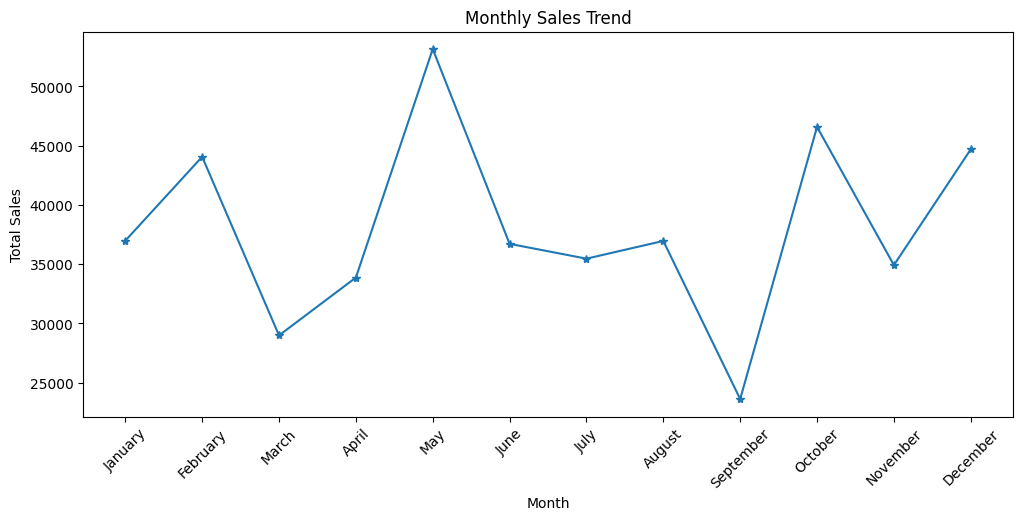

In [44]:
month_order =["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_sales = monthly_sales.reindex(month_order)
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker ="*")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45)
plt.show()

## Observation

The monthly sales trend shows noticeable variation in sales throughout the year. May records the highest sales, while September records the lowest sales. These fluctuations can help the business identify periods of stronger and weaker demand and plan inventory and promotions accordingly.

In [45]:
df["Quarter"]= df["Date"].dt.quarter

In [46]:
quarter_sales = df.groupby("Quarter")["Total Amount"].sum()

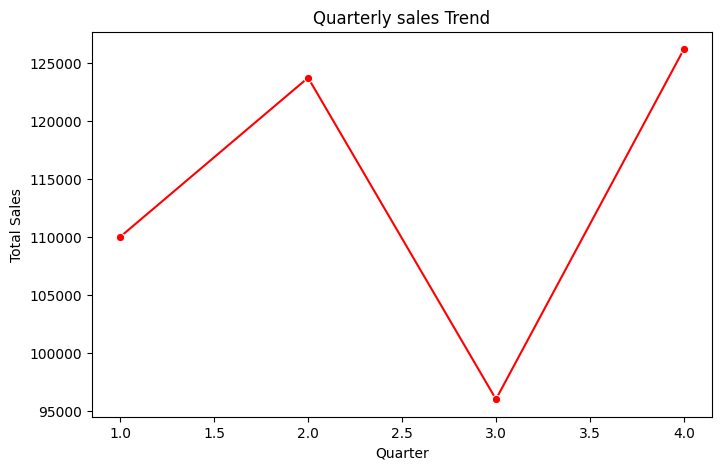

In [47]:
plt.figure(figsize=(8,5))
sns.lineplot(x= quarter_sales.index,y=quarter_sales.values,marker="o",color ="Red")
plt.title("Quarterly sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

## Observation

The quarterly sales analysis shows that the fourth quarter records the highest sales, while the third quarter records the lowest sales. This indicates that sales performance varies considerably across quarters and can help the business plan inventory and marketing activities according to seasonal demand.

<Axes: xlabel='Age', ylabel='Count'>

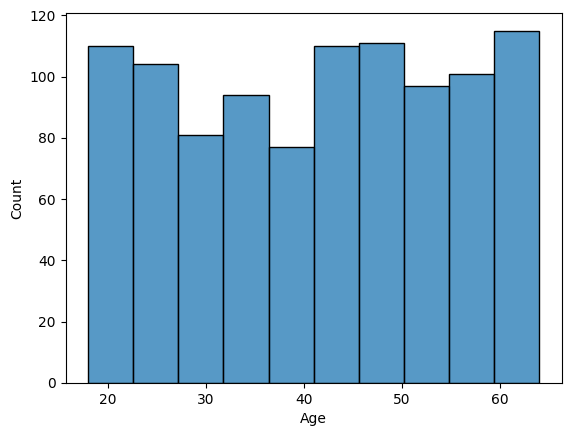

In [48]:
sns.histplot(df["Age"],bins = 10)

<Axes: xlabel='Gender', ylabel='count'>

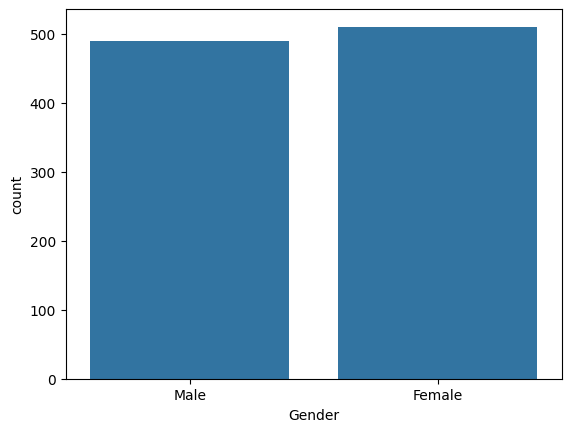

In [49]:
sns.countplot(data= df,x="Gender")

## OBSERVATION
The number of female is  slightly more than male. This indicates a fairly balanced customer distribution by gender

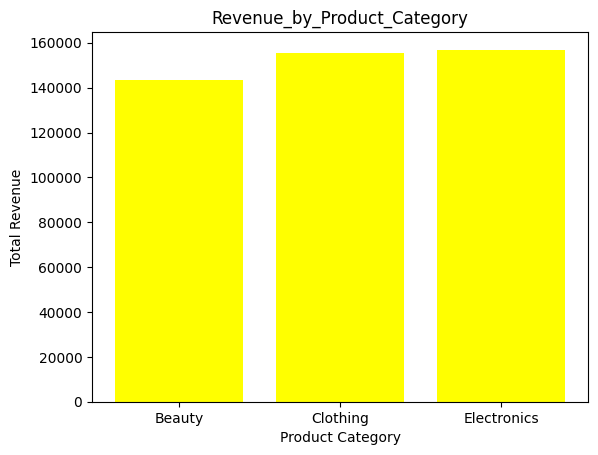

In [50]:
revenue_by_product = df.groupby("Product Category")["Total Amount"].sum()
plt.bar(  revenue_by_product.index,revenue_by_product.values ,color = "yellow" )
plt.title("Revenue_by_Product_Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

## OBSERVATION
 The bar chart compares the total revenue generated by each product category . it help us identify that electronics contributes the most to overall sales revenue followed by clothing and beauty .Beauty category require additional marketing attention.

## DATASET LIMITATION
The dataset contains product categories rather than individual product names.
so,individual top-10 product analysis cannot be performed .Instead,product categories are analyzed based on total revenue and quantity sold

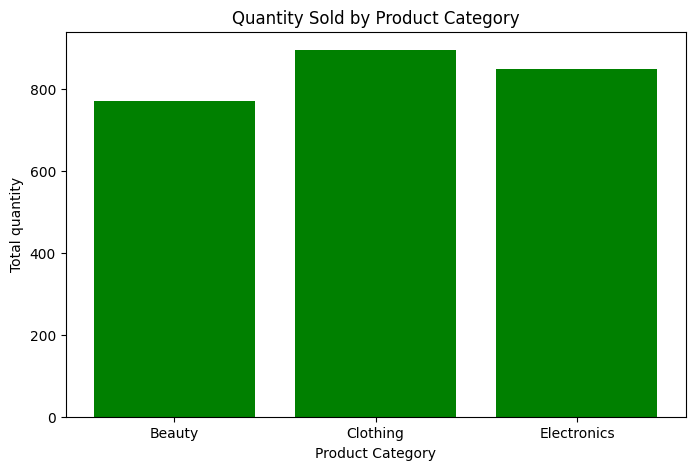

In [51]:
quantity_sold = df.groupby("Product Category")["Quantity"].sum()
plt.figure(figsize=(8,5))
plt.bar(quantity_sold.index,quantity_sold.values,color = "green")
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total quantity")
plt.show()

## OSERVATION
The chart shows the total quantity sold across the three product categories . Clothing category has highest sales but beauty category needs attention cause it has the lowest sales.This indicates stronger customer demand for clothing and suggests that the Beauty category may benefit from additional promotional strategies.

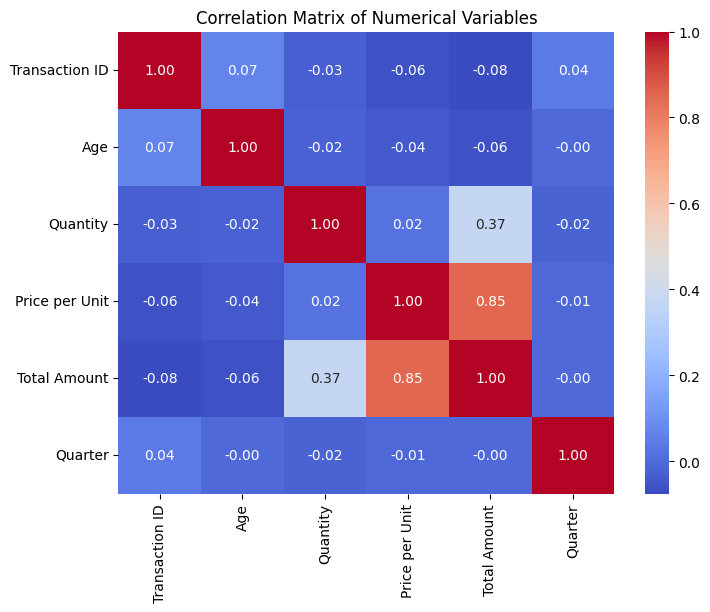

In [52]:
plt.figure(figsize= (8,6))
correlation = df.corr(numeric_only= True)
sns.heatmap(
    correlation,
    annot= True,
    cmap = "coolwarm",
    fmt =".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

## Observation

The correlation heatmap shows that Price per Unit has the strongest positive
relationship with Total Amount, with a correlation of 0.85. Quantity also has
a moderate positive relationship with Total Amount, with a correlation of 0.37.
Age has almost no relationship with Total Amount, with a correlation of -0.06.
This suggests that the amount spent in a transaction is influenced more by
product price and quantity than by customer age.

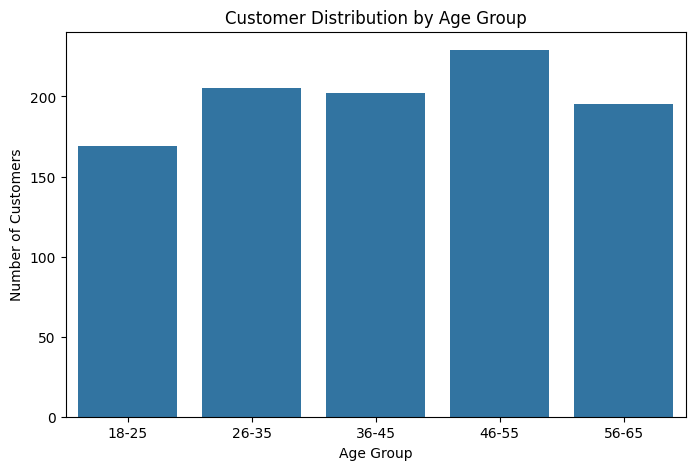

In [53]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Age Group")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

## Observation

The age-group distribution shows how customers are distributed across different age ranges.  The age group  of 46-55 is our  major customer segments. This helps identify the minor customer segments  is 18-25 which needs  age-specific marketing and product strategies.

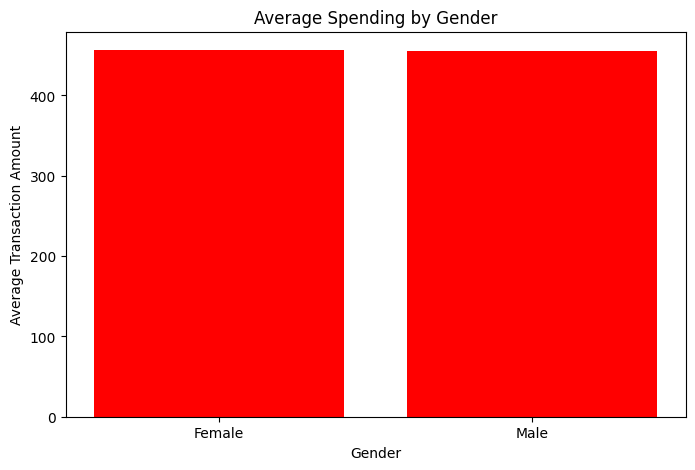

In [54]:
# Average spending by gender

avg_spending_gender = df.groupby("Gender")["Total Amount"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_spending_gender.index, avg_spending_gender.values,color = "red")

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Transaction Amount")

plt.show()

## Observation

- Average spending is very similar for male and female customers.
- Female customers have a slightly higher average transaction amount than female customers.
- The small difference suggests that gender has little impact on average spending in this dataset.
- Therefore, marketing strategies should focus more on product preferences and customer segments rather than gender alone.

# Conclusion

## Key Findings

- Clothing generated the highest total revenue among the three product categories.
- The 46–55 age group represents the largest customer segment, while 18–25 is the smallest.
- Monthly sales fluctuate throughout the year, with May showing high sales and September showing the lowest sales.
- Male and female customers have very similar average transaction amounts.
- Price per Unit has a strong positive relationship with Total Amount.

## Business Recommendations

1. **Focus on the 26–55 age groups:** Since these customers represent a large portion of the customer base, targeted campaigns and personalized offers can be developed for them.

2. **Strengthen Clothing sales:** Clothing generates the highest revenue, so the business should maintain sufficient inventory and consider expanding successful clothing products.

3. **Improve low-performing periods:** Sales drop significantly in September, so seasonal promotions and targeted discounts can be introduced during weaker months.

4. **Use product-focused marketing:** Since average spending is very similar between male and female customers, marketing should focus more on product preferences and customer behavior rather than gender alone.